# 🌸 Clasificación de Iris con Red Neuronal - Versión 2.0

**Objetivo:** Construir un modelo que clasifique flores Iris evitando data leakage y sobreajuste.

**Correcciones respecto al modelo anterior:**
- ✅ Scaler ajustado SOLO con datos de entrenamiento
- ✅ División estratificada de datos
- ✅ Arquitectura simplificada para evitar sobreajuste
- ✅ EarlyStopping y Dropout para mejor generalización

## 1. Carga de Librerías

In [1]:
# Librerías básicas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Métricas
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

# Configuración
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")
print("Librerías cargadas correctamente ✓")

TensorFlow version: 2.21.0
Librerías cargadas correctamente ✓


## 2. Carga del Dataset

In [2]:
# Cargar dataset
df = pd.read_csv('dataset3_iris_fisher (1).csv')

# Mostrar información básica
print("="*50)
print("ESTRUCTURA DEL DATASET")
print("="*50)
print(f"\nDimensiones: {df.shape[0]} filas x {df.shape[1]} columnas")
print(f"\nColumnas: {list(df.columns)}")
print("\nPrimeras 5 filas:")
df.head()

ESTRUCTURA DEL DATASET

Dimensiones: 150 filas x 6 columnas

Columnas: ['longitud_sepalo_cm', 'ancho_sepalo_cm', 'longitud_petalo_cm', 'ancho_petalo_cm', 'especie_id', 'especie']

Primeras 5 filas:


,longitud_sepalo_cm,ancho_sepalo_cm,longitud_petalo_cm,ancho_petalo_cm,especie_id,especie
0,5.1,3.5,1.4,0.2,0,Iris Setosa
1,4.9,3.0,1.4,0.2,0,Iris Setosa
2,4.7,3.2,1.3,0.2,0,Iris Setosa
3,4.6,3.1,1.5,0.2,0,Iris Setosa
4,5.0,3.6,1.4,0.2,0,Iris Setosa


In [3]:
# Información del dataset
print("Información del dataset:")
print(df.info())
print("\nEstadísticas descriptivas:")
df.describe()

Información del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitud_sepalo_cm  150 non-null    float64
 1   ancho_sepalo_cm     150 non-null    float64
 2   longitud_petalo_cm  150 non-null    float64
 3   ancho_petalo_cm     150 non-null    float64
 4   especie_id          150 non-null    int64  
 5   especie             150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB
None

Estadísticas descriptivas:


,longitud_sepalo_cm,ancho_sepalo_cm,longitud_petalo_cm,ancho_petalo_cm,especie_id
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [4]:
# Verificar valores nulos
print("Valores nulos por columna:")
print(df.isnull().sum())

Valores nulos por columna:
longitud_sepalo_cm    0
ancho_sepalo_cm       0
longitud_petalo_cm    0
ancho_petalo_cm       0
especie_id            0
especie               0
dtype: int64


## 3. Análisis Exploratorio de Datos (EDA)

Distribución de especies:
especie
Iris Setosa        50
Iris Versicolor    50
Iris Virginica     50
Name: count, dtype: int64


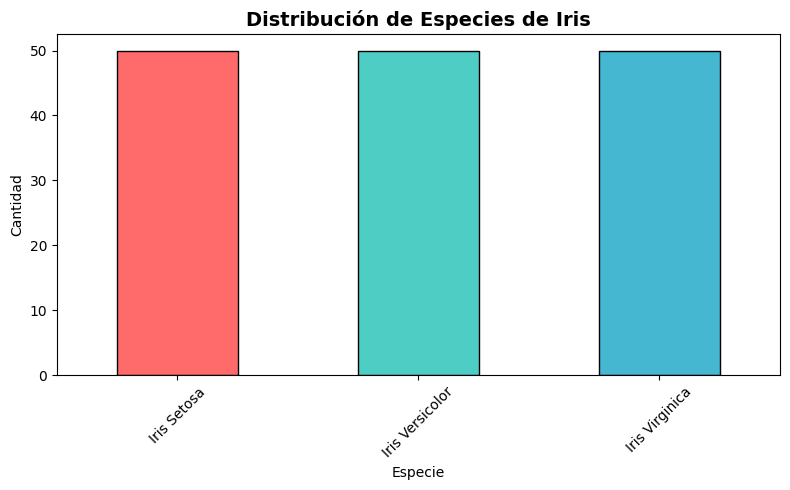

In [5]:
# Distribución de clases
print("Distribución de especies:")
print(df['especie'].value_counts())

plt.figure(figsize=(8, 5))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
df['especie'].value_counts().plot(kind='bar', color=colors, edgecolor='black')
plt.title('Distribución de Especies de Iris', fontsize=14, fontweight='bold')
plt.xlabel('Especie')
plt.ylabel('Cantidad')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

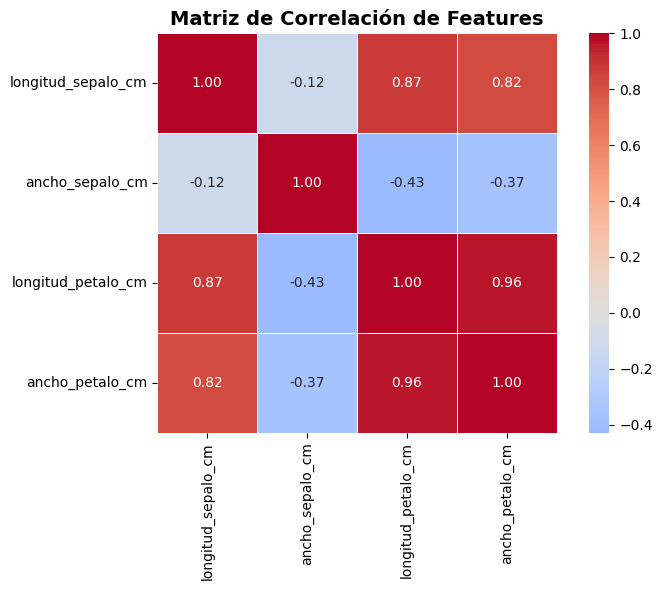

In [6]:
# Matriz de correlación (solo features numéricos)
features_numericos = ['longitud_sepalo_cm', 'ancho_sepalo_cm', 'longitud_petalo_cm', 'ancho_petalo_cm']

plt.figure(figsize=(8, 6))
correlation_matrix = df[features_numericos].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True, linewidths=0.5)
plt.title('Matriz de Correlación de Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

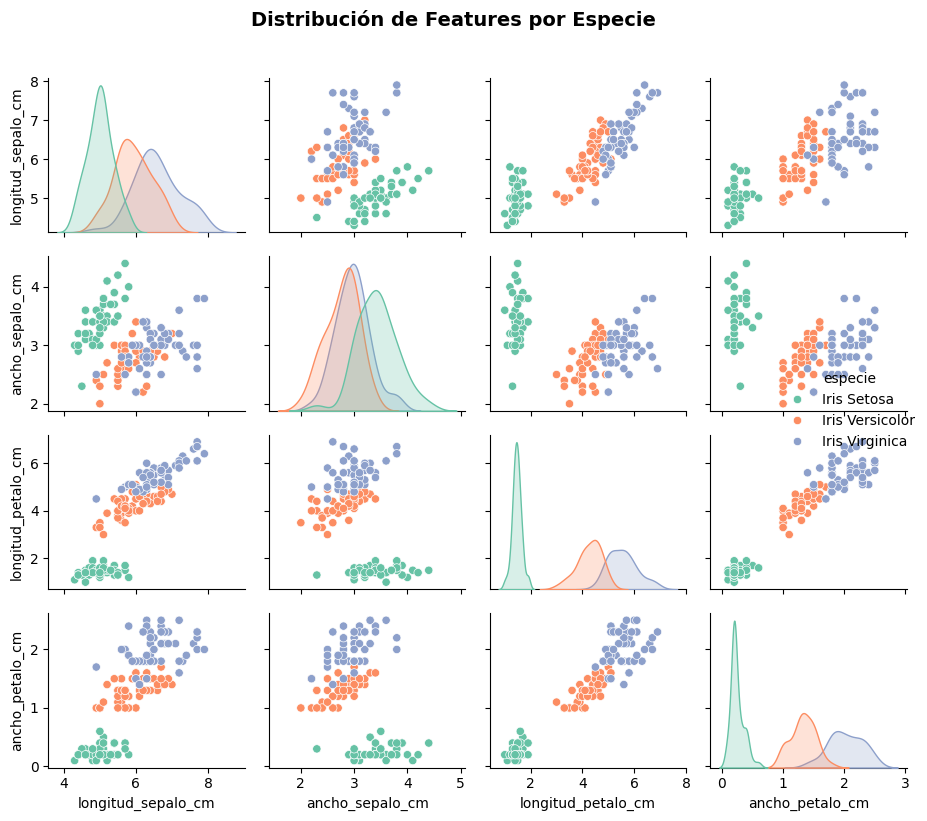

In [7]:
# Pairplot para visualizar separabilidad de clases
sns.pairplot(df, hue='especie', vars=features_numericos, 
             palette='Set2', diag_kind='kde', height=2)
plt.suptitle('Distribución de Features por Especie', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. División de Datos (⚠️ CRÍTICO)

**Reglas aplicadas:**
- Se usa `stratify=y` para mantener proporción de clases
- Se divide en 3 conjuntos: Train (60%), Validation (20%), Test (20%)
- El conjunto de test NO se toca hasta la evaluación final

In [8]:
# Preparar features (X) y target (y)
X = df[features_numericos].values
y = df['especie_id'].values  # Ya está codificado numéricamente

print(f"Shape de X: {X.shape}")
print(f"Shape de y: {y.shape}")
print(f"Clases únicas: {np.unique(y)}")

Shape de X: (150, 4)
Shape de y: (150,)
Clases únicas: [0 1 2]


In [9]:
# PASO 1: Separar Test (20%) del resto
# IMPORTANTE: stratify=y mantiene la proporción de clases en cada conjunto
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, 
    test_size=0.20,      # 20% para test
    random_state=42, 
    stratify=y           # ⚠️ CRÍTICO: Estratificación por clase
)

# PASO 2: Del 80% restante, separar Validation (25% de 80% = 20% del total)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, 
    test_size=0.25,      # 25% de 80% = 20% del total
    random_state=42, 
    stratify=y_temp      # ⚠️ CRÍTICO: Estratificación por clase
)

print("="*50)
print("DIVISIÓN DE DATOS COMPLETADA")
print("="*50)
print(f"\n📊 Train set:      {X_train.shape[0]} muestras ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"📊 Validation set: {X_val.shape[0]} muestras ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"📊 Test set:       {X_test.shape[0]} muestras ({X_test.shape[0]/len(X)*100:.1f}%)")

DIVISIÓN DE DATOS COMPLETADA

📊 Train set:      90 muestras (60.0%)
📊 Validation set: 30 muestras (20.0%)
📊 Test set:       30 muestras (20.0%)


In [10]:
# Verificar que la estratificación funcionó correctamente
print("\nDistribución de clases por conjunto:")
print(f"Train:      {np.bincount(y_train)}")
print(f"Validation: {np.bincount(y_val)}")
print(f"Test:       {np.bincount(y_test)}")


Distribución de clases por conjunto:
Train:      [30 30 30]
Validation: [10 10 10]
Test:       [10 10 10]


## 5. Normalización (⚠️ CRÍTICO - Evitar Data Leakage)

**¿Qué es Data Leakage?**
Es cuando información del conjunto de test "se filtra" al entrenamiento, causando resultados irrealmente buenos.

**¿Cómo lo evitamos?**
- El scaler se ajusta (fit) ÚNICAMENTE con datos de entrenamiento
- Los conjuntos de validation y test solo se transforman, NUNCA se hace fit con ellos
- Esto simula el escenario real donde no conocemos los datos futuros

In [11]:
# Crear el scaler
scaler = StandardScaler()

# ⚠️ CRÍTICO: fit_transform SOLO con X_train
# Esto calcula media y desviación estándar ÚNICAMENTE de los datos de entrenamiento
X_train_scaled = scaler.fit_transform(X_train)

# ⚠️ CRÍTICO: transform (SIN fit) para validation y test
# Usamos las estadísticas calculadas de X_train para transformar estos conjuntos
# Esto evita que información de validation/test influya en el preprocesamiento
X_val_scaled = scaler.transform(X_val)    # Solo transform, NO fit
X_test_scaled = scaler.transform(X_test)  # Solo transform, NO fit

print("✅ Normalización completada SIN data leakage")
print(f"\nMedia del scaler (calculada solo de train): {scaler.mean_}")
print(f"Std del scaler (calculada solo de train): {scaler.scale_}")

✅ Normalización completada SIN data leakage

Media del scaler (calculada solo de train): [5.83666667 3.01333333 3.75111111 1.19777778]
Std del scaler (calculada solo de train): [0.86132327 0.41397799 1.76221101 0.75703776]


In [12]:
# Verificar la normalización
print("Estadísticas después de normalización:")
print(f"\nX_train_scaled - Media: {X_train_scaled.mean(axis=0).round(6)}")
print(f"X_train_scaled - Std:   {X_train_scaled.std(axis=0).round(2)}")
print(f"\nX_val_scaled - Media:   {X_val_scaled.mean(axis=0).round(2)}")
print(f"X_test_scaled - Media:  {X_test_scaled.mean(axis=0).round(2)}")
print("\n💡 Nota: Solo train tiene media ~0 y std ~1 porque el scaler se ajustó con él.")
print("   Validation y test tienen valores ligeramente diferentes, lo cual es CORRECTO.")

Estadísticas después de normalización:

X_train_scaled - Media: [-0.  0. -0.  0.]
X_train_scaled - Std:   [1. 1. 1. 1.]

X_val_scaled - Media:   [0.02 0.34 0.04 0.04]
X_test_scaled - Media:  [ 0.02  0.19 -0.02 -0.03]

💡 Nota: Solo train tiene media ~0 y std ~1 porque el scaler se ajustó con él.
   Validation y test tienen valores ligeramente diferentes, lo cual es CORRECTO.


In [13]:
# Convertir etiquetas a one-hot encoding
num_classes = len(np.unique(y))
y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_val_cat = to_categorical(y_val, num_classes=num_classes)
y_test_cat = to_categorical(y_test, num_classes=num_classes)

print(f"\nOne-hot encoding aplicado:")
print(f"y_train_cat shape: {y_train_cat.shape}")
print(f"Ejemplo: clase {y_train[0]} -> {y_train_cat[0]}")


One-hot encoding aplicado:
y_train_cat shape: (90, 3)
Ejemplo: clase 2 -> [0. 0. 1.]


## 6. Arquitectura del Modelo (Simplificada)

**Diseño intencional para evitar sobreajuste:**
- Pocas neuronas por capa (el dataset es pequeño)
- Solo 1-2 capas ocultas
- Dropout para regularización
- Arquitectura simple que debe generalizar bien

In [14]:
# Definir arquitectura simplificada
model = Sequential([
    # Capa de entrada
    Input(shape=(4,)),  # 4 features de entrada
    
    # Primera capa oculta - pocas neuronas para dataset pequeño
    Dense(16, activation='relu'),
    Dropout(0.2),  # 20% dropout para regularización
    
    # Segunda capa oculta - aún más pequeña
    Dense(8, activation='relu'),
    Dropout(0.2),  # 20% dropout
    
    # Capa de salida - 3 clases con softmax
    Dense(3, activation='softmax')
])

# Compilar modelo
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Mostrar resumen
print("="*50)
print("ARQUITECTURA DEL MODELO")
print("="*50)
model.summary()

ARQUITECTURA DEL MODELO


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 243 (972.00 B)

 Trainable params: 243 (972.00 B)

 Non-trainable params: 0 (0.00 B)

## 7. Prevención de Sobreajuste

**Estrategias implementadas:**

1. **EarlyStopping**: Detiene el entrenamiento si validation loss no mejora
   - `patience=10`: Espera 10 épocas sin mejora antes de parar
   - `restore_best_weights=True`: Recupera los pesos del mejor modelo

2. **Dropout (ya incluido en arquitectura)**: 
   - "Apaga" aleatoriamente 20% de neuronas durante entrenamiento
   - Evita que el modelo dependa demasiado de neuronas específicas

3. **Arquitectura simple**:
   - Menos parámetros = menos capacidad de memorizar datos

In [15]:
# Configurar EarlyStopping
early_stopping = EarlyStopping(
    monitor='val_loss',           # Monitorear loss de validación
    patience=10,                   # Esperar 10 épocas sin mejora
    restore_best_weights=True,     # Restaurar mejores pesos
    verbose=1                      # Mostrar cuando se active
)

print("✅ EarlyStopping configurado")
print("   - Monitorea: val_loss")
print("   - Patience: 10 épocas")
print("   - Restaura mejores pesos: Sí")

✅ EarlyStopping configurado
   - Monitorea: val_loss
   - Patience: 10 épocas
   - Restaura mejores pesos: Sí


## 8. Entrenamiento del Modelo

In [16]:
# Entrenar el modelo
print("="*50)
print("INICIANDO ENTRENAMIENTO")
print("="*50)

history = model.fit(
    X_train_scaled, y_train_cat,
    epochs=100,                              # Máximo de épocas
    batch_size=16,                           # Batch pequeño para dataset pequeño
    validation_data=(X_val_scaled, y_val_cat),  # ⚠️ CRÍTICO: Datos de validación separados
    callbacks=[early_stopping],              # Aplicar EarlyStopping
    verbose=1
)

print(f"\n✅ Entrenamiento finalizado en {len(history.history['loss'])} épocas")

INICIANDO ENTRENAMIENTO
Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - accuracy: 0.4778 - loss: 1.0822 - val_accuracy: 0.4667 - val_loss: 1.0109
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4889 - loss: 1.0412 - val_accuracy: 0.5000 - val_loss: 0.9458
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.4889 - loss: 1.0401 - val_accuracy: 0.6667 - val_loss: 0.8928
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5556 - loss: 0.9706 - val_accuracy: 0.7667 - val_loss: 0.8461
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.4667 - loss: 0.9723 - val_accuracy: 0.8000 - val_loss: 0.8066
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6556 - loss: 0.8517 - val_accuracy: 0.8000 - val_loss: 0.7705
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6667 - loss: 0.8380 - val_accuracy: 0.8000 - val_loss: 0.7381
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7333 - loss: 0.7801 - val_accu

## 9. Evaluación del Modelo

In [17]:
# Evaluar en los tres conjuntos
print("="*50)
print("EVALUACIÓN DEL MODELO")
print("="*50)

# Evaluar en Train
train_loss, train_acc = model.evaluate(X_train_scaled, y_train_cat, verbose=0)
print(f"\n📊 TRAIN:")
print(f"   Loss: {train_loss:.4f}")
print(f"   Accuracy: {train_acc:.4f} ({train_acc*100:.2f}%)")

# Evaluar en Validation
val_loss, val_acc = model.evaluate(X_val_scaled, y_val_cat, verbose=0)
print(f"\n📊 VALIDATION:")
print(f"   Loss: {val_loss:.4f}")
print(f"   Accuracy: {val_acc:.4f} ({val_acc*100:.2f}%)")

# Evaluar en Test (PRIMERA VEZ que usamos test)
test_loss, test_acc = model.evaluate(X_test_scaled, y_test_cat, verbose=0)
print(f"\n📊 TEST:")
print(f"   Loss: {test_loss:.4f}")
print(f"   Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")

EVALUACIÓN DEL MODELO

📊 TRAIN:
   Loss: 0.1591
   Accuracy: 0.9667 (96.67%)

📊 VALIDATION:
   Loss: 0.3147
   Accuracy: 0.8000 (80.00%)

📊 TEST:
   Loss: 0.2750
   Accuracy: 0.8333 (83.33%)


In [18]:
# Análisis de resultados
print("\n" + "="*50)
print("ANÁLISIS DE GENERALIZACIÓN")
print("="*50)

diff_train_val = train_acc - val_acc
diff_train_test = train_acc - test_acc

print(f"\nDiferencia Train vs Validation: {diff_train_val:.4f}")
print(f"Diferencia Train vs Test: {diff_train_test:.4f}")

if diff_train_val > 0.1:
    print("\n⚠️ Posible sobreajuste: Train muy superior a Validation")
elif diff_train_val < -0.05:
    print("\n🤔 Validation superior a Train (puede ser ruido estadístico)")
else:
    print("\n✅ Buena generalización: diferencias razonables entre conjuntos")

if train_acc == 1.0 and val_acc == 1.0 and test_acc == 1.0:
    print("\n⚠️ ADVERTENCIA: Resultados perfectos pueden indicar problemas")
else:
    print("\n✅ Resultados realistas (no perfectos en todos los conjuntos)")


ANÁLISIS DE GENERALIZACIÓN

Diferencia Train vs Validation: 0.1667
Diferencia Train vs Test: 0.1333

⚠️ Posible sobreajuste: Train muy superior a Validation

✅ Resultados realistas (no perfectos en todos los conjuntos)


In [19]:
# Predicciones para métricas detalladas
y_pred_proba = model.predict(X_test_scaled, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)

# Mapeo de clases
clases = ['Iris Setosa', 'Iris Versicolor', 'Iris Virginica']

# Classification Report
print("\n" + "="*50)
print("CLASSIFICATION REPORT (Test Set)")
print("="*50)
print(classification_report(y_test, y_pred, target_names=clases))


CLASSIFICATION REPORT (Test Set)
                 precision    recall  f1-score   support

    Iris Setosa       1.00      1.00      1.00        10
Iris Versicolor       0.86      0.60      0.71        10
 Iris Virginica       0.69      0.90      0.78        10

       accuracy                           0.83        30
      macro avg       0.85      0.83      0.83        30
   weighted avg       0.85      0.83      0.83        30



## 10. Visualización de Resultados

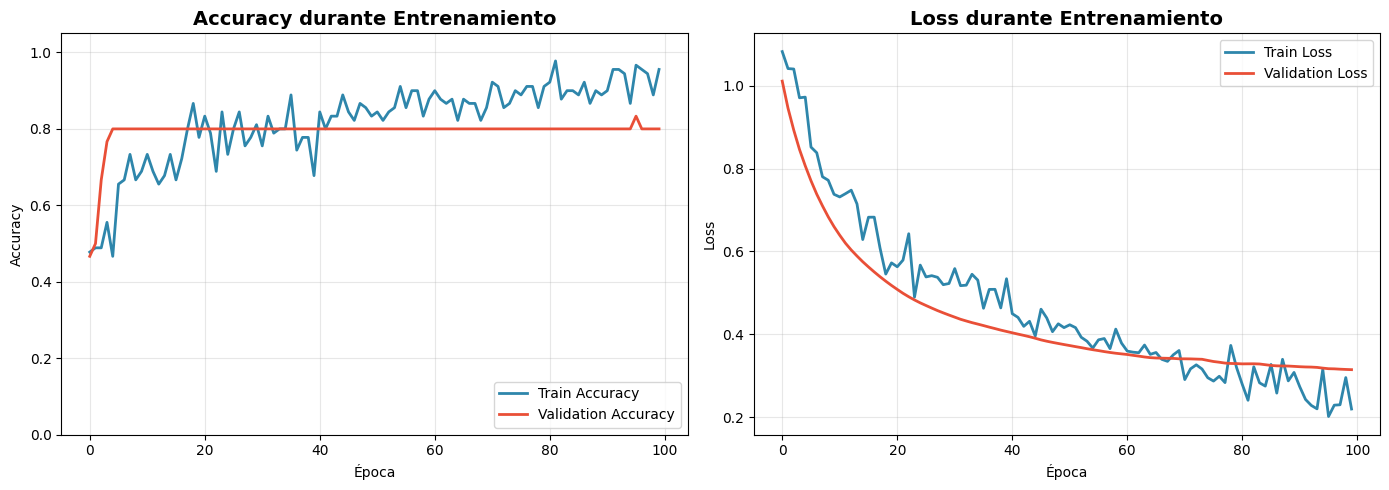

💡 Si las curvas de Train y Validation están cercanas, el modelo generaliza bien.
   Si Train es mucho mejor que Validation, hay sobreajuste.


In [20]:
# Gráfica de Accuracy: Train vs Validation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2, color='#2E86AB')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2, color='#E94F37')
axes[0].set_title('Accuracy durante Entrenamiento', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Accuracy')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([0, 1.05])

# Loss
axes[1].plot(history.history['loss'], label='Train Loss', linewidth=2, color='#2E86AB')
axes[1].plot(history.history['val_loss'], label='Validation Loss', linewidth=2, color='#E94F37')
axes[1].set_title('Loss durante Entrenamiento', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Loss')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("💡 Si las curvas de Train y Validation están cercanas, el modelo generaliza bien.")
print("   Si Train es mucho mejor que Validation, hay sobreajuste.")

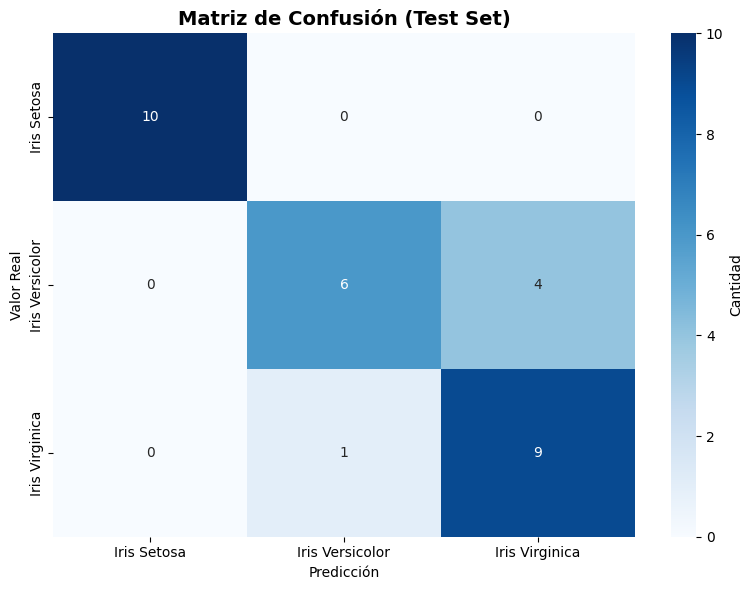


📊 Total de errores en Test: 5 de 30 muestras
   Tasa de error: 16.67%


In [21]:
# Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=clases, yticklabels=clases,
            cbar_kws={'label': 'Cantidad'})
plt.title('Matriz de Confusión (Test Set)', fontsize=14, fontweight='bold')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.tight_layout()
plt.show()

# Análisis de errores
total_errores = cm.sum() - np.trace(cm)
print(f"\n📊 Total de errores en Test: {total_errores} de {len(y_test)} muestras")
print(f"   Tasa de error: {total_errores/len(y_test)*100:.2f}%")

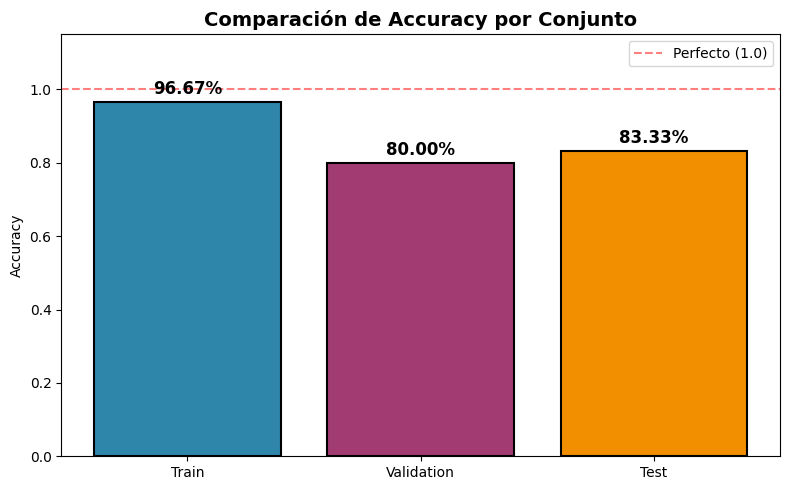

In [22]:
# Gráfica comparativa de métricas por conjunto
conjuntos = ['Train', 'Validation', 'Test']
accuracies = [train_acc, val_acc, test_acc]
colors = ['#2E86AB', '#A23B72', '#F18F01']

plt.figure(figsize=(8, 5))
bars = plt.bar(conjuntos, accuracies, color=colors, edgecolor='black', linewidth=1.5)

# Añadir valores sobre las barras
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{acc:.2%}', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title('Comparación de Accuracy por Conjunto', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy')
plt.ylim([0, 1.15])
plt.axhline(y=1.0, color='red', linestyle='--', alpha=0.5, label='Perfecto (1.0)')
plt.legend()
plt.tight_layout()
plt.show()

## 11. Predicción Personalizada

Ingresa los 4 valores de una flor para predecir su especie.

In [23]:
def predecir_especie(longitud_sepalo, ancho_sepalo, longitud_petalo, ancho_petalo):
    """
    Predice la especie de Iris dados los 4 features.
    
    Parámetros:
    - longitud_sepalo (cm)
    - ancho_sepalo (cm)
    - longitud_petalo (cm)
    - ancho_petalo (cm)
    """
    # Crear array con los valores de entrada
    entrada = np.array([[longitud_sepalo, ancho_sepalo, longitud_petalo, ancho_petalo]])
    
    # ⚠️ IMPORTANTE: Usar el scaler ya entrenado (con datos de train)
    entrada_scaled = scaler.transform(entrada)
    
    # Hacer predicción
    probabilidades = model.predict(entrada_scaled, verbose=0)
    clase_predicha = np.argmax(probabilidades)
    
    # Mapeo de clases
    especies = ['Iris Setosa', 'Iris Versicolor', 'Iris Virginica']
    
    # Mostrar resultados
    print("="*50)
    print("PREDICCIÓN DE ESPECIE")
    print("="*50)
    print(f"\n📏 Valores de entrada:")
    print(f"   Longitud sépalo: {longitud_sepalo} cm")
    print(f"   Ancho sépalo:    {ancho_sepalo} cm")
    print(f"   Longitud pétalo: {longitud_petalo} cm")
    print(f"   Ancho pétalo:    {ancho_petalo} cm")
    
    print(f"\n🔮 Probabilidades:")
    for i, (esp, prob) in enumerate(zip(especies, probabilidades[0])):
        barra = '█' * int(prob * 20)
        print(f"   {esp}: {prob:.2%} {barra}")
    
    print(f"\n🌸 PREDICCIÓN: {especies[clase_predicha]}")
    print(f"   Confianza: {probabilidades[0][clase_predicha]:.2%}")
    
    return especies[clase_predicha], probabilidades[0]

In [24]:
# Ejemplo 1: Valores típicos de Iris Setosa
print("\n" + "#"*50)
print("# EJEMPLO 1: Valores típicos de Setosa")
print("#"*50)
predecir_especie(
    longitud_sepalo=5.0,
    ancho_sepalo=3.5,
    longitud_petalo=1.4,
    ancho_petalo=0.2
)


##################################################
# EJEMPLO 1: Valores típicos de Setosa
##################################################
PREDICCIÓN DE ESPECIE

📏 Valores de entrada:
   Longitud sépalo: 5.0 cm
   Ancho sépalo:    3.5 cm
   Longitud pétalo: 1.4 cm
   Ancho pétalo:    0.2 cm

🔮 Probabilidades:
   Iris Setosa: 100.00% ███████████████████
   Iris Versicolor: 0.00% 
   Iris Virginica: 0.00% 

🌸 PREDICCIÓN: Iris Setosa
   Confianza: 100.00%


('Iris Setosa',
 array([9.9995339e-01, 3.8050057e-05, 8.5519314e-06], dtype=float32))

In [25]:
# Ejemplo 2: Valores típicos de Iris Versicolor
print("\n" + "#"*50)
print("# EJEMPLO 2: Valores típicos de Versicolor")
print("#"*50)
predecir_especie(
    longitud_sepalo=5.9,
    ancho_sepalo=2.8,
    longitud_petalo=4.5,
    ancho_petalo=1.3
)


##################################################
# EJEMPLO 2: Valores típicos de Versicolor
##################################################
PREDICCIÓN DE ESPECIE

📏 Valores de entrada:
   Longitud sépalo: 5.9 cm
   Ancho sépalo:    2.8 cm
   Longitud pétalo: 4.5 cm
   Ancho pétalo:    1.3 cm

🔮 Probabilidades:
   Iris Setosa: 1.58% 
   Iris Versicolor: 73.98% ██████████████
   Iris Virginica: 24.44% ████

🌸 PREDICCIÓN: Iris Versicolor
   Confianza: 73.98%


('Iris Versicolor', array([0.01581273, 0.73978245, 0.24440476], dtype=float32))

In [26]:
# Ejemplo 3: Valores típicos de Iris Virginica
print("\n" + "#"*50)
print("# EJEMPLO 3: Valores típicos de Virginica")
print("#"*50)
predecir_especie(
    longitud_sepalo=6.7,
    ancho_sepalo=3.0,
    longitud_petalo=5.5,
    ancho_petalo=2.1
)


##################################################
# EJEMPLO 3: Valores típicos de Virginica
##################################################
PREDICCIÓN DE ESPECIE

📏 Valores de entrada:
   Longitud sépalo: 6.7 cm
   Ancho sépalo:    3.0 cm
   Longitud pétalo: 5.5 cm
   Ancho pétalo:    2.1 cm

🔮 Probabilidades:
   Iris Setosa: 0.14% 
   Iris Versicolor: 2.35% 
   Iris Virginica: 97.51% ███████████████████

🌸 PREDICCIÓN: Iris Virginica
   Confianza: 97.51%


('Iris Virginica', array([0.0013831 , 0.02351388, 0.97510296], dtype=float32))

In [27]:
# ====================================================
# INGRESA TUS PROPIOS VALORES AQUÍ
# ====================================================

# Modifica estos valores para hacer tu propia predicción
mi_prediccion = predecir_especie(
    longitud_sepalo=5.5,  # Cambia este valor
    ancho_sepalo=2.5,     # Cambia este valor
    longitud_petalo=4.0,  # Cambia este valor
    ancho_petalo=1.2      # Cambia este valor
)

PREDICCIÓN DE ESPECIE

📏 Valores de entrada:
   Longitud sépalo: 5.5 cm
   Ancho sépalo:    2.5 cm
   Longitud pétalo: 4.0 cm
   Ancho pétalo:    1.2 cm

🔮 Probabilidades:
   Iris Setosa: 1.18% 
   Iris Versicolor: 78.07% ███████████████
   Iris Virginica: 20.75% ████

🌸 PREDICCIÓN: Iris Versicolor
   Confianza: 78.07%


## 📋 Resumen Final

### Medidas implementadas para evitar Data Leakage:
1. ✅ Scaler ajustado **únicamente** con datos de entrenamiento
2. ✅ División estratificada con `stratify=y`
3. ✅ Conjunto de test **nunca usado** hasta evaluación final
4. ✅ Validation data separado del train

### Medidas para evitar Sobreajuste:
1. ✅ Arquitectura simple (16 → 8 → 3 neuronas)
2. ✅ Dropout del 20% en capas ocultas
3. ✅ EarlyStopping con patience=10
4. ✅ Batch size pequeño (16)

### Interpretación de Resultados:
- Si Train ≈ Validation ≈ Test → **Buena generalización** ✓
- Si Train >> Validation/Test → **Sobreajuste** ⚠️
- Si todo = 1.0 → **Posible problema de validación** ⚠️

In [28]:
# Resumen final del modelo
print("="*60)
print("RESUMEN FINAL DEL MODELO")
print("="*60)
print(f"\n📊 Resultados:")
print(f"   Train Accuracy:      {train_acc:.4f} ({train_acc*100:.2f}%)")
print(f"   Validation Accuracy: {val_acc:.4f} ({val_acc*100:.2f}%)")
print(f"   Test Accuracy:       {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"\n⏱️ Entrenamiento:")
print(f"   Épocas ejecutadas: {len(history.history['loss'])}")
print(f"\n🔧 Arquitectura:")
print(f"   Capas: Input(4) → Dense(16) → Dropout → Dense(8) → Dropout → Dense(3)")
print(f"   Total parámetros: {model.count_params():,}")
print("\n" + "="*60)
print("Modelo entrenado correctamente sin data leakage ✓")
print("="*60)

RESUMEN FINAL DEL MODELO

📊 Resultados:
   Train Accuracy:      0.9667 (96.67%)
   Validation Accuracy: 0.8000 (80.00%)
   Test Accuracy:       0.8333 (83.33%)

⏱️ Entrenamiento:
   Épocas ejecutadas: 100

🔧 Arquitectura:
   Capas: Input(4) → Dense(16) → Dropout → Dense(8) → Dropout → Dense(3)
   Total parámetros: 243

Modelo entrenado correctamente sin data leakage ✓
